In [1]:
%matplotlib inline
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import seaborn as sns
from programmable_cubes_UDP import ProgrammableCubes
from programmable_cubes_UDP import programmable_cubes_UDP
import numpy as np
from pygmo import problem

TARGET


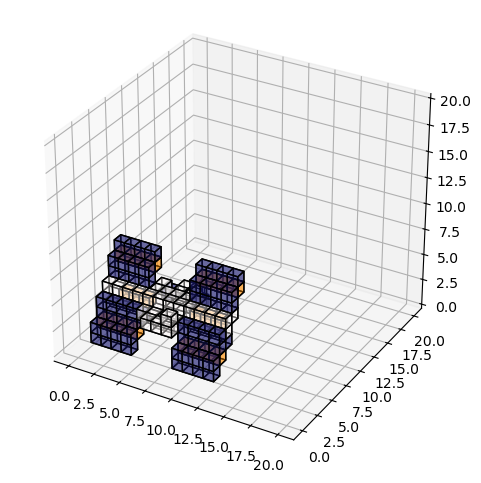

INITIAL


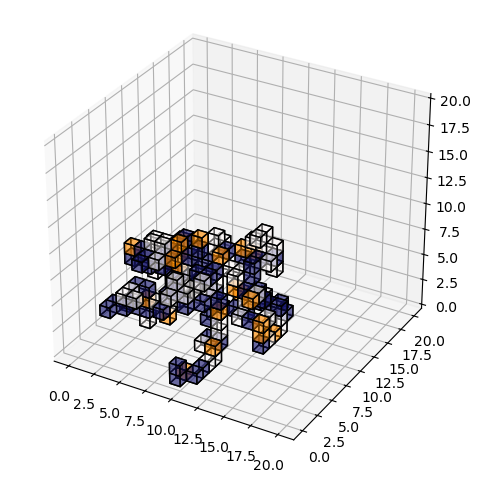

In [ ]:


udp = programmable_cubes_UDP("ISS")
prob = problem(udp)
print(f"Refernce fitness: {udp.fitness(np.array([-1]))}")
ti = udp.initial_cube_types
ci = udp.final_cube_positions
ct = udp.target_cube_positions
tt = udp.target_cube_types
types = np.arange(np.max(ti)+1)

print("TARGET")
udp.plot("none",cube_type_to_plot=types,custom_config=udp.target_cube_positions,custom_cube_types=udp.target_cube_types)
print("INITIAL")
udp.plot("none",cube_type_to_plot=types,custom_config=udp.final_cube_positions,custom_cube_types=udp.initial_cube_types)

def plot(c,t):
    udp.plot("none",cube_type_to_plot=types,custom_config=c,custom_cube_types=t)
        
def debug_plot(c,t):
    udp.debug_plot("none",cube_type_to_plot=types,custom_config=c,custom_cube_types=t)
        


cubes = ProgrammableCubes(ci)



In [3]:




print(np.sum(ci == ct,axis=1) == 3)

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True False False False]


## Experiments to understand intesection and wrong cubes

In [19]:

def contains_coord(arr, coord):
    for id,c in enumerate(arr):
        if np.sum(c==coord) == len(coord):
            return id
    return -1



# Get the wrong ones
print(ci.shape)
print(ct.shape)
all = np.concat([ci,ct])
print(all.shape)
# This finds coordinates of cubes which are not in their place or empty target place(IGNORES types)
arr, uniq_cnt = np.unique(all, axis=0, return_counts=True)
wrong = arr[uniq_cnt==1]
print(wrong)
# Find empty target place ids:
wrong_ci_ids = []
for coord in wrong:
    id = contains_coord(ci,coord) 
    if id != -1:
        wrong_ci_ids.append(id)
wrong_ci_ids = np.array(wrong_ci_ids)
print(wrong_ci_ids)

# Find empty target place ids:
wrong_ct_ids = []
for coord in wrong:
    id = contains_coord(ct,coord) 
    if id != -1:
        wrong_ct_ids.append(id)
wrong_ct_ids = np.array(wrong_ct_ids)
print(wrong_ct_ids)

(148, 3)
(148, 3)
(296, 3)
[[-1  0  1]
 [-1  1  1]
 [-1  3  0]
 [-1  4  4]
 [-1  4  5]
 [ 0  1  1]
 [ 0  1  2]
 [ 0  2  0]
 [ 0  2  2]
 [ 0  3  0]
 [ 0  3  1]
 [ 0  3  3]
 [ 0  4  2]
 [ 0  4  3]
 [ 0  4  4]
 [ 0  4  5]
 [ 0  5  3]
 [ 0  5  4]
 [ 0  5  5]
 [ 0  5  6]
 [ 0  6  2]
 [ 0  6  3]
 [ 0  6  4]
 [ 0  6  5]
 [ 0  6  6]
 [ 0  6  7]
 [ 0  7  2]
 [ 0  8  2]
 [ 1  1  2]
 [ 1  2  0]
 [ 1  2  1]
 [ 1  2  5]
 [ 1  3 -1]
 [ 1  3  0]
 [ 1  3  3]
 [ 1  3  5]
 [ 1  4  2]
 [ 1  4  3]
 [ 1  4  4]
 [ 1  4  5]
 [ 1  4  6]
 [ 1  5  3]
 [ 1  5  4]
 [ 1  5  5]
 [ 1  5  6]
 [ 1  6  5]
 [ 1  6  6]
 [ 1  6  7]
 [ 2  2  0]
 [ 2  2  1]
 [ 2  3  2]
 [ 2  3  3]
 [ 2  3  5]
 [ 2  4  2]
 [ 2  4  3]
 [ 2  4  5]
 [ 2  4  6]
 [ 2  5  3]
 [ 2  5  4]
 [ 2  5  6]
 [ 2  6  4]
 [ 2  6  5]
 [ 2  6  6]
 [ 2  6  7]
 [ 2  7  5]
 [ 3  2  0]
 [ 3  3  0]
 [ 3  3  3]
 [ 3  4  4]
 [ 3  4  5]
 [ 3  6  7]
 [ 3  7  4]
 [ 3  7  5]
 [ 4  3  2]
 [ 4  3  3]
 [ 4  4  2]
 [ 4  4  3]
 [ 4  4  4]
 [ 4  5  2]
 [ 4  5  5]
 [ 4  6  4]
 

## Useful functions

In [ ]:
def is_accessible(c,cubes:ProgrammableCubes):
    """ Checks if there is at least one cube in some direction """
    DIRS = [[1,0,0],[-1,0,0],[0,1,0],[0,-1,0],[0,0,1],[0,0,-1]]
    for d in DIRS:
        idx = np.where((cubes.cube_position == [c[0]+d[0],c[1]+d[1],c[2]+d[2]]).all(axis=1))[0]
        if idx.size > 0:
            return True
    return False

#is_accessible([5,5,5],cubes)

True

## Intersection and difference implementation for algorithm

In [20]:
def get_wrong_cube_ids(arr1,arr2):
    """
    
    """
    arr, cnt = np.unique(np.concat([arr1,arr2]), axis=0, return_counts=True)
    wrong = arr[cnt==1]
    arr1_ids = []
    for coord in wrong:
        id = contains_coord(arr1,coord) 
        if id != -1:
            arr1_ids.append(id)
    arr1_ids = np.array(arr1_ids)

    arr2_ids = []
    for coord in wrong:
        id = contains_coord(arr2,coord) 
        if id != -1:
            arr2_ids.append(id)
    arr2_ids = np.array(arr2_ids)

    return arr1_ids,arr2_ids

print(get_wrong_cube_ids(ci,ct))

(array([ 26, 100,   0,  48,  87,  32,  66,  51, 117,  41,  76,  45,  72,
         8,  97,  70,  17,  65,  83,  40, 115,  78, 123,   3,  55,  14,
        64,  96,  85,  61,  57,  63,   7,  90,  42,  16, 124, 107,   4,
         6,  86,  43,  18, 113,  27,  36, 104,  47,  62,  77,  29,  60,
       116, 108, 126,  10,  11, 134,   1,  20, 142, 143,  71,  67, 130,
       144,  37, 136,  73, 145,  24,  46, 132,  13, 103,  30, 131,  56,
        19,  12, 102,  54,  95, 146,  34,  98,  25, 110,  44,  39, 139,
       135,  52, 105, 121,  50,   5, 106, 119,  74,  91,  28,  15,  69]), array([  0,  16,  47,  32,  59,  90, 102, 116, 124, 132, 140,   1,   9,
        48,  33,  60,  91,  71, 103, 117, 125, 133, 141,   2,  10,  26,
        49,  34,  61,  72, 104, 126, 134, 142,   3,  50,  93, 143,  51,
        63,  94, 114,  83,  44,  52,  36,  64,  95,  42, 107,  81,  84,
        87,  53,  37,  65,  96,  43,  76, 108,  82,  85,  88,  89,  77,
       109, 115,  86,   4,  12,  38,  67,  98,  78, 110, 128,

## Finding path from coord to coord

### Random walk

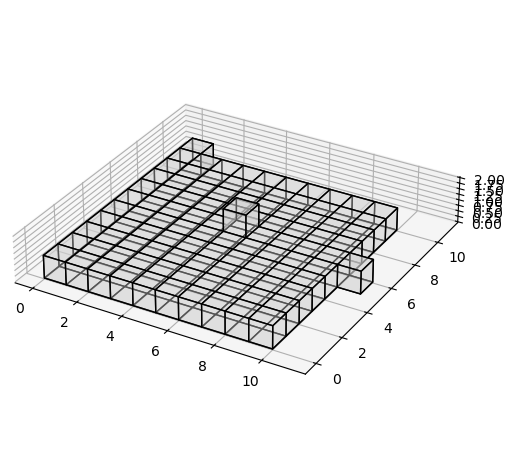

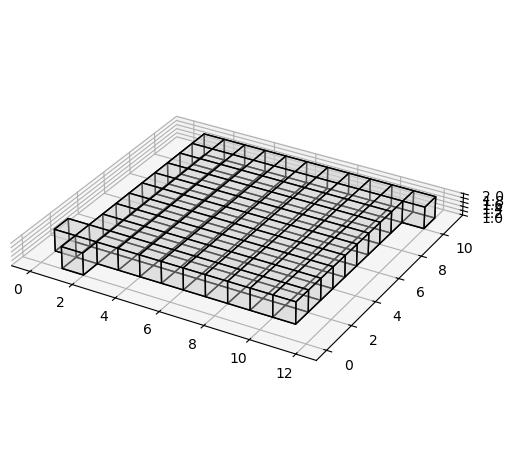

[0 0 1] [ 0 10  0]
[0 1 1] [ 0 10  0]
[1 1 1] [ 0 10  0]
[2 1 1] [ 0 10  0]
[2 1 1] [ 0 10  0]
[2 2 1] [ 0 10  0]
[1 2 1] [ 0 10  0]
[0 2 1] [ 0 10  0]
[-1  2  0] [ 0 10  0]
[-1  3  0] [ 0 10  0]
[-1  3  0] [ 0 10  0]
[-1  3  0] [ 0 10  0]
[-1  4  0] [ 0 10  0]
[-1  5  0] [ 0 10  0]
[-1  6  0] [ 0 10  0]
[ 0  6 -1] [ 0 10  0]
[ 0  6 -1] [ 0 10  0]
[ 0  6 -1] [ 0 10  0]
[ 0  6 -1] [ 0 10  0]
[ 0  6 -1] [ 0 10  0]
[ 1  6 -1] [ 0 10  0]
[ 2  6 -1] [ 0 10  0]
[ 2  6 -1] [ 0 10  0]
[ 2  6 -1] [ 0 10  0]
[ 1  6 -1] [ 0 10  0]
[ 0  6 -1] [ 0 10  0]
[-1  6  0] [ 0 10  0]
[-1  6  0] [ 0 10  0]
[0 6 1] [ 0 10  0]
[0 7 1] [ 0 10  0]
[-1  7  0] [ 0 10  0]
[-1  8  0] [ 0 10  0]
[0 8 1] [ 0 10  0]
[0 9 1] [ 0 10  0]
[0 8 1] [ 0 10  0]
[0 8 1] [ 0 10  0]
[1 8 1] [ 0 10  0]
[1 8 1] [ 0 10  0]
[1 7 1] [ 0 10  0]
[2 7 1] [ 0 10  0]
[2 7 1] [ 0 10  0]
[1 7 1] [ 0 10  0]
[0 7 1] [ 0 10  0]
[1 7 1] [ 0 10  0]
[1 8 1] [ 0 10  0]
[1 8 1] [ 0 10  0]
[1 9 1] [ 0 10  0]
[0 9 1] [ 0 10  0]
[-1  9  0] [ 0 10  0]


In [6]:
wi,wt = get_wrong_cube_ids(ci,ct)
# Pick 1 coord of wrong cube and 1 coord of empty target
c1 = ci[wi[0]]
c2 = ct[wt[0]]

# Find the path
alg = []
plot(ct,tt)
plot(ci,ti)
while np.sum(c1 == c2) != 3 and len(alg) < udp.get_nix():
    rot = np.random.randint(0,6)
    out = cubes.apply_single_update_step(wi[0],rot)
    c1 = cubes.cube_position[wi[0]]
    print(c1,c2)
    alg.append(wi[0])
    alg.append(rot)
    
    #plot(cubes.cube_position,ti)

print(len(alg))
print(alg)

### Axis alignment

- works pretty well
- TODO: better halt condition

In [69]:
wi,wt = get_wrong_cube_ids(ci,ct)
# Pick 1 coord of wrong cube and 1 coord of empty target
c1 = ci[wi[0]]
c2 = ct[wt[0]]

ROT_X = [2,3,4,5]
ROT_Y = [0,1,2,3]
ROT_Z = [0,1,4,5]
ROTS = [ROT_X,ROT_Y,ROT_Z]
def inv_rot(rot):
    match rot:
        case 0:
            return 1
        case 1:
            return 0
        case 2:
            return 3
        case 3:
            return 2
        case 4:
            return 5
        case 5:
            return 4
        
def dist_metric(a,b):
    return np.sum(np.abs(a-b))

def find_path_to_position(id:int,c,cubes : ProgrammableCubes, budget:int = 500, verbose:bool = False):
    """
    finds path for cube with index "id" to the coordinate "c" with valid moves on "cubes"

    returns chromosomes as alg, coordinates in path, success
    """
    # Initialize variables
    alg = []
    path = []
    c1 = cubes.cube_position[id]
    c2 = c
    # Speedups
    if not is_accessible(c2,cubes):
        return [],[],False
    
    if verbose:
        print(f"Moving cube on position {c1} to {c2}")
    # Main loop
    while np.sum(c1 == c2) != 3 and len(alg) < budget:
        # rots clockwise,counter-clockwise around x,z,y
        # 0,1 - to change y,z
        # 2,3 to change x,y
        # 4,5 to change x,z
        # idea 1
        # if x is not equal
        # rotate 2,3,4,5 and find where closer
        #dir = 0 # x
        changed_smth = False
        for dir in np.arange(0,3):
            diff = np.abs(c1 - c2)
            dist = dist_metric(c1,c2)
            if diff[dir] != 0: # change only coordinates which dont match
                for rot in ROTS[dir]:
                    # Apply rotation
                    res = cubes.apply_single_update_step(id,rot)
                    # Compute new difference
                    c1 = cubes.cube_position[id]
                    new_dist = dist_metric(c1,c2)
                    if res == 1 and dist > new_dist: # legal and better
                        path.append(c1.copy())
                        alg.append(id)
                        alg.append(rot)
                        dist = new_dist
                        changed_smth = True
                        continue
                    elif res == 1: # legal but not better, revert
                        cubes.apply_single_update_step(id,inv_rot(rot))
                        c1 = cubes.cube_position[id]
                        continue
        if changed_smth == False: # break if all moves are tried
            break
    success = dist_metric(c1,c2) == 0
    return alg,path,success
        
id = wi[0]
alg = []
path = []
cubes.reset(ci)
for i in np.arange(len(wi)):
    tmp_alg, tmp_path, success = find_path_to_position(wi[i],ct[wt[i]],cubes)
    alg.extend(tmp_alg)
    path.extend(tmp_path)
#find_path_to_position(wi[1],wt[1],cubes,alg,path)
print(alg)
path = np.array(path)


[np.int64(26), 2, np.int64(26), 4, np.int64(26), 2, np.int64(100), 1, np.int64(100), 1, np.int64(0), 5, np.int64(0), 5, np.int64(0), 5, np.int64(48), 4, np.int64(87), 4, np.int64(87), 4, np.int64(41), 5, np.int64(17), 2, np.int64(17), 1, np.int64(17), 1, np.int64(17), 1, np.int64(65), 0, np.int64(65), 3, np.int64(40), 2, np.int64(40), 2, np.int64(40), 2, np.int64(40), 2, np.int64(115), 2, np.int64(115), 2, np.int64(115), 2, np.int64(85), 3, np.int64(85), 3, np.int64(63), 2, np.int64(63), 5, np.int64(63), 2, np.int64(7), 3, np.int64(16), 4, np.int64(124), 3, np.int64(124), 4, np.int64(107), 2, np.int64(107), 0, np.int64(6), 3, np.int64(6), 3, np.int64(86), 1, np.int64(18), 3, np.int64(18), 4, np.int64(104), 5, np.int64(62), 4, np.int64(62), 3, np.int64(77), 1, np.int64(77), 2, np.int64(108), 3, np.int64(108), 3, np.int64(108), 3, np.int64(10), 3, np.int64(134), 1, np.int64(1), 1, np.int64(1), 1, np.int64(1), 4, np.int64(1), 2, np.int64(54), 4, np.int64(95), 2, np.int64(95), 4, np.int64(

[[-1  1  0]
 [ 0  1  0]
 [ 0  2  0]
 [-1  2  1]
 [ 0  3  1]
 [-1  3  1]
 [-1  3  2]
 [ 0  3  3]
 [ 0  4  4]
 [-1  4  4]
 [ 0  4  3]
 [ 0  4  6]
 [ 0  7  3]
 [ 1  6  3]
 [ 1  5  3]
 [ 1  4  3]
 [ 1  2  2]
 [ 1  3  3]
 [ 1  4  0]
 [ 1  4  1]
 [ 1  4  2]
 [ 1  5  3]
 [ 1  4  1]
 [ 1  4  2]
 [ 1  5  2]
 [ 2  5  4]
 [ 2  4  3]
 [ 3  4  1]
 [ 2  4  2]
 [ 2  5  3]
 [ 3  4  6]
 [ 3  3  3]
 [ 4  4  3]
 [ 3  4  4]
 [ 4  6  3]
 [ 3  6  3]
 [ 4  6  4]
 [ 4  6  3]
 [ 4  1  4]
 [ 5  2  4]
 [ 5  2  3]
 [ 5  1  3]
 [ 5  2  4]
 [ 5  3  3]
 [ 6  4  5]
 [ 6  5  4]
 [ 6  6  5]
 [ 6  6  4]
 [ 6  5  3]
 [ 7 -1 -1]
 [ 6  3 -1]
 [ 6  3  5]
 [ 6  4  5]
 [ 6  4  4]
 [ 6  4  3]
 [ 9  6  2]
 [10  6  7]
 [ 9  6  6]
 [ 9  5  6]
 [ 9  4  6]
 [ 9  3  5]
 [10  6  3]
 [ 9  6  3]
 [10  6  7]
 [ 9  6  6]
 [ 9  5  6]
 [11  4  5]
 [10  4  5]
 [10  4  6]
 [ 9  4  6]
 [10  6  3]
 [ 9  6  4]
 [11  6  5]
 [10  6  5]
 [11  7  2]
 [10  7  2]
 [10  6  3]
 [10  6  4]
 [11  6  1]
 [11  5  2]]


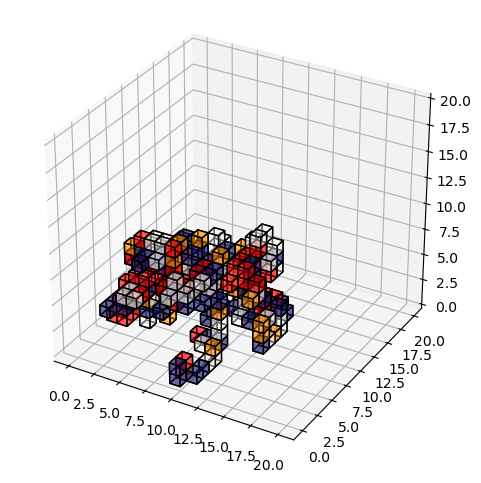

In [70]:
print(path)
debug_plot(np.concat([ci,path]), np.concat([ti,-np.ones(shape=path.shape[0])]))

## Pairing methods

In [ ]:



def pair_closest(vecs1,vec2):



## REPEAT, Repeat, repeat...


Budget status: 1.33322223148071 % used, successes: 8
Budget status: 2.0998250145821182 % used, successes: 12
Budget status: 2.649779185067911 % used, successes: 15
Budget status: 3.2497291892342304 % used, successes: 17
Budget status: 3.683026414465461 % used, successes: 18
Budget status: 4.232980584951254 % used, successes: 19
Budget status: 5.03291392383968 % used, successes: 25
Budget status: 5.6328639280059996 % used, successes: 29
Budget status: 6.166152820598284 % used, successes: 33
Budget status: 6.8327639363386385 % used, successes: 39


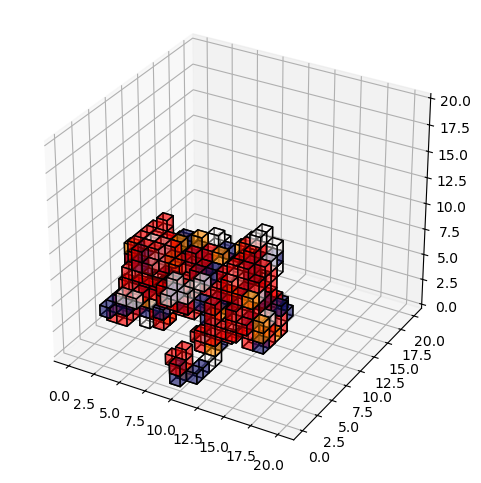

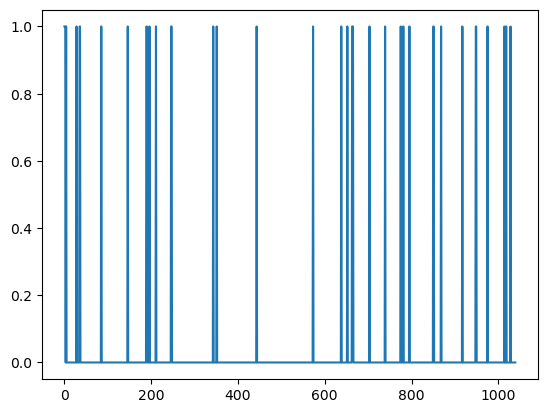

In [87]:
alg = []
path = []
iter = 0
cubes.reset(ci)
ESCAPE = 10
placed_stat = []
successes = 0
while len(alg) < udp.get_nix() and iter < ESCAPE:
    # Get places which are wrong
    wi, wt = get_wrong_cube_ids(ci,ct)
    assert(len(wi) == len(wt)) # otherwise unsolvable
    # Pair them
    src_dest_all = [[wi[i],wt[(i+iter)%len(wi)]] for i in np.arange(len(wi))]

    # Find paths between them
    for src_dest in src_dest_all:
        tmp_alg,tmp_path,success = find_path_to_position(src_dest[0],ct[src_dest[1]],cubes,100)
        alg.extend(tmp_alg)
        path.extend(tmp_path)
        placed_stat.append((int)(success))
        successes += (int)(success)

    iter += 1
    print(f"Budget status: {len(alg)/udp.get_nix()*100} % used, successes: {successes}")
path = np.array(path)
debug_plot(np.concat([ci,path]), np.concat([ti,-np.ones(shape=path.shape[0])]))
plt.plot(np.array(placed_stat))


## Evaluation of the chromosome

[26  2 26 ...  0  0 -1]
 Achieved fitness: [np.float64(-0.02492710170487947)]
Initial config


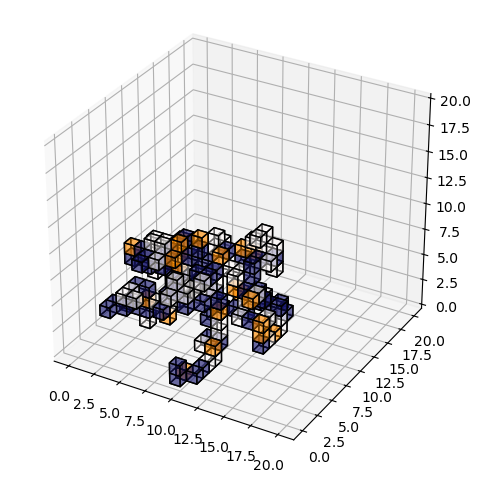

Achieved config


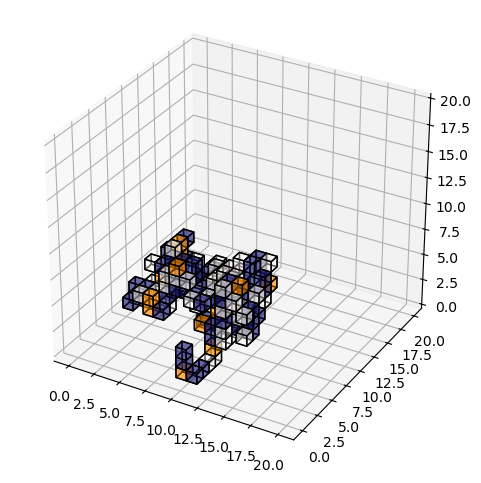

Target config


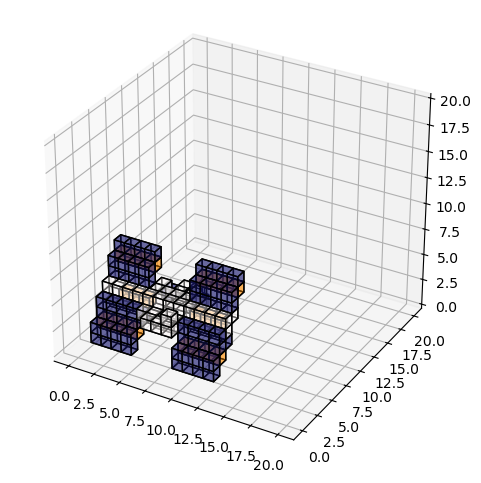

In [84]:

chrom = alg.copy()
#chrom = [1,0]
chrom = np.array(chrom)
def remove_illegal_moves_from_chromosome(chromosome):
    """ From tutorial 1"""
    cubes = ProgrammableCubes(ci)

    filtered_chromosome = []

    for i in range(int(len(chromosome)/2)):
        cube_id = chromosome[i*2]
        move = chromosome[i*2+1]
        done = cubes.apply_single_update_step(cube_id, move)
        # done is 1 if the move is legal and 0 otherwise
        if done == 1:
            filtered_chromosome += [cube_id, move]
    # The part to be evaluated by the fitness function ends here,
    # thus we add -1
    filtered_chromosome += [-1]
    
    # Fill up the remaining chromosome with 0s (will not be evaluated)
    if len(filtered_chromosome) < udp.get_nix():
        for i in range(udp.get_nix() - 1 - len(filtered_chromosome)):
            filtered_chromosome += [0]
        # Mandatory entry of -1 at the very end
        filtered_chromosome += [-1]
        
    return np.array(filtered_chromosome)
chrom = remove_illegal_moves_from_chromosome(chrom)
print(chrom)
print(f" Achieved fitness: {udp.fitness(chrom)}")
print("Initial config")
plot(ci,ti)
print("Achieved config")
udp.plot("ensemble",types)
print("Target config")
udp.plot("target",types)
